In [1]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
def generate_data_indices(num_samples=2000, seq_len=50, motif="CGACCGAACTCC"):
    X = []
    y = []
    motif_positions = [] # 新增：记录 Motif 的真实位置
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    
    for _ in range(num_samples):
        # 生成随机背景序列 (0-3)
        seq_int = np.random.randint(0, 4, seq_len)
        label = 0
        start_idx = -1 # 默认没有 Motif
        
        # 50% 概率插入 Motif
        if np.random.rand() > 0.5:
            start_idx = np.random.randint(0, seq_len - len(motif))
            for i, char in enumerate(motif):
                seq_int[start_idx + i] = base_to_int[char]
            label = 1
            
        X.append(seq_int)
        y.append(label)
        motif_positions.append(start_idx)
        
    return np.array(X, dtype=np.int64), np.array(y, dtype=np.float32), np.array(motif_positions)



In [3]:
X, y = generate_data_indices()
print(f"Data shape: {X.shape}") # Should be (2000, 50)
print(f"Sample sequence: {X[0]}")

Data shape: (2000, 50)
Sample sequence: [0 3 3 2 2 2 2 0 2 2 3 2 3 2 3 1 2 3 3 1 0 1 2 3 2 3 2 3 0 0 0 0 0 3 0 3 3
 1 3 3 3 3 0 3 1 2 3 0 2 2]


In [4]:

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        # 创建一个足够长的矩阵 (max_len, d_model)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # 偶数位用 sin，奇数位用 cos
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # 注册为 buffer，不是参数，不参与更新，但会随模型保存
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        # 加上对应长度的位置编码
        x = x + self.pe[:x.size(1), :].unsqueeze(0)
        return x

In [5]:

class MotifTransformer(nn.Module):
    def __init__(self, vocab_size=4, d_model=32, nhead=4, num_layers=1, max_len=50):
        super(MotifTransformer, self).__init__()
        
        # 1. Embedding: 把 0,1,2,3 变成向量
        self.embedding = nn.Embedding(vocab_size, d_model)
        
        # 2. Positional Encoding: 注入位置信息
        self.pos_encoder = PositionalEncoding(d_model, max_len)
        
        # 3. Transformer Block (这里为了教学清晰，我们只用 1 层，且手动定义)
        # 如果 num_layers > 1，可以用 nn.TransformerEncoder
        self.self_attn = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 2), # 扩大维度
            nn.ReLU(),
            nn.Linear(d_model * 2, d_model)  # 缩回维度
        )
        self.norm2 = nn.LayerNorm(d_model)
        
        # 4. Classifier
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: [batch, seq_len]
        
        # Step 1: Embedding + Pos
        x = self.embedding(x) * math.sqrt(32) # scaling is a trick in original paper
        x = self.pos_encoder(x) # [batch, seq_len, d_model]
        
        # Step 2: Self-Attention
        # need_weights=True 会返回 attention map，这对我们需要分析 motif 很重要！
        attn_output, attn_weights = self.self_attn(x, x, x, need_weights=True)
        
        # Step 3: Add & Norm (Residual Connection)
        x = self.norm1(x + attn_output)
        
        # Step 4: Feed Forward + Add & Norm
        ff_output = self.ffn(x)
        x = self.norm2(x + ff_output)
        
        # Step 5: Pooling & Output
        # 我们把所有位置的特征取平均 (Global Average Pooling)
        # 也可以取第一个位置 (CLS token) 的特征
        x_mean = x.mean(dim=1) # [batch, d_model]
        
        logits = self.fc(x_mean)
        
        return logits, attn_weights

Start Training Transformer...
Epoch [5/20], Train Acc: 70.94%, Test Acc: 71.50%
Epoch [10/20], Train Acc: 71.94%, Test Acc: 73.00%
Epoch [15/20], Train Acc: 71.75%, Test Acc: 74.00%
Epoch [20/20], Train Acc: 71.31%, Test Acc: 73.75%


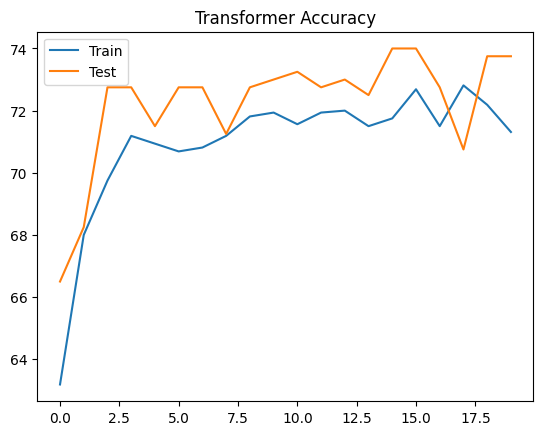

In [6]:

# 数据切分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 初始化模型
model = MotifTransformer(d_model=32, nhead=4) # 32维向量，4个头
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练循环
train_acc_history = []
test_acc_history = []

print("Start Training Transformer...")
epochs = 20
for epoch in range(epochs):
    model.train()
    correct = 0; total = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs, _ = model(inputs) # 这里的 _ 是 attention weights，训练时不需要
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        
        predicted = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_acc = 100 * correct / total
    
    # Validation
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs, _ = model(inputs)
            predicted = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_acc = 100 * correct / total
    
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    
    if (epoch+1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%')

# 画个简单的收敛图
plt.plot(train_acc_history, label='Train')
plt.plot(test_acc_history, label='Test')
plt.legend()
plt.title('Transformer Accuracy')
plt.show()

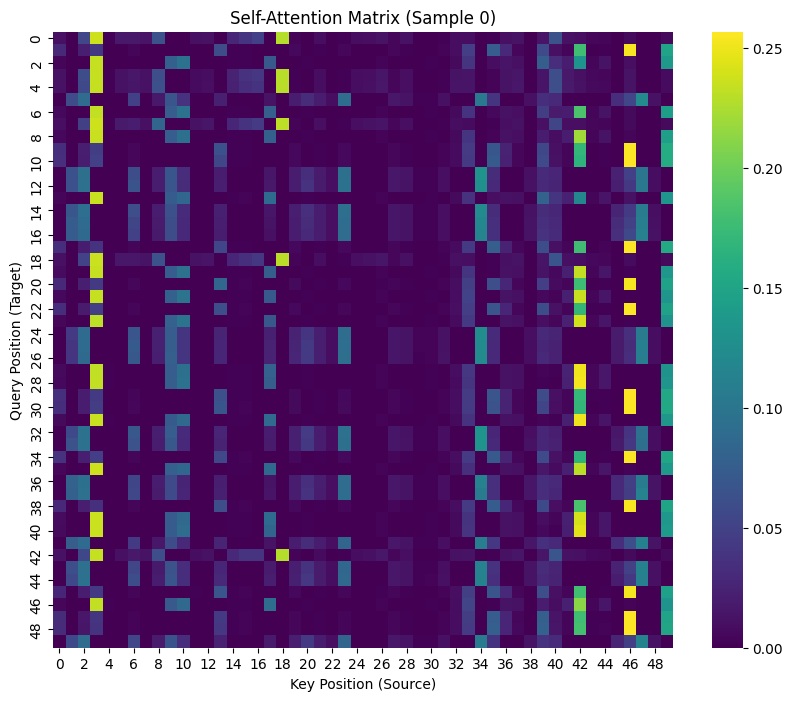

In [7]:

def visualize_attention(model, dataset, sample_idx=None):
    model.eval()
    
    # 找一个正样本 (有 Motif 的)
    if sample_idx is None:
        for i in range(len(dataset)):
            _, label = dataset[i]
            if label == 1:
                sample_idx = i
                break
    
    input_seq, label = dataset[sample_idx]
    input_tensor = input_seq.unsqueeze(0) # [1, 50]
    
    with torch.no_grad():
        _, attn_weights = model(input_tensor)
        # attn_weights shape: [batch, 1, seq_len, seq_len] (average over heads if needed)
        # 但 nn.MultiheadAttention 返回的是 [batch, seq_len, seq_len] (如果 average_attn_weights=True，默认是True)
        # 或者是 [batch, num_heads, seq_len, seq_len] (如果我们需要单独看头)
        # 这里默认返回平均后的权重: [1, 50, 50]
    
    attn_matrix = attn_weights.squeeze().numpy()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(attn_matrix, cmap='viridis')
    plt.title(f'Self-Attention Matrix (Sample {sample_idx})')
    plt.xlabel('Key Position (Source)')
    plt.ylabel('Query Position (Target)')
    plt.show()

# 运行可视化
visualize_attention(model, test_dataset)